# Notebook 04: Baseline Random Forest Model

## AI-Based Identification of Novel Drug Targets for Depression

### Overview

This notebook develops a Random Forest machine learning model to predict
drug–target interactions associated with depression-related proteins.

The processed drug–target interaction dataset generated in the previous stage is
used to train and evaluate a classification model. Molecular fingerprints
generated from drug SMILES structures are used as input features, while binary
activity labels derived from pChEMBL values are used as the prediction target.

A baseline Random Forest model is first developed and evaluated. Cross-validation
and hyperparameter optimisation are then performed to improve model performance
and identify the best model configuration. The final optimised model provides a
benchmark for comparison with more advanced approaches, including protein
embeddings and Graph Neural Networks, in later stages of the dissertation.


### Dataset

The input dataset for this notebook is:

`clean_drug_target_interactions.pkl`

The dataset contains cleaned drug–protein interaction records, molecular
fingerprint features generated from drug SMILES structures, and binary activity
labels derived from pChEMBL scores.

This dataset represents the main training data used for the machine learning
stage of the project.


### Project Workflow

This notebook represents the fourth stage of the project:

1. Load the processed drug–target interaction dataset.
2. Prepare molecular fingerprint features and activity labels.
3. Split the dataset into training and testing sets.
4. Train a baseline Random Forest classification model.
5. Evaluate model performance using classification metrics.
6. Validate model performance using cross-validation.
7. Optimise model parameters using hyperparameter tuning.
8. Analyse important molecular fingerprint features.
9. Save the final optimised model and evaluation results for future comparison.


### Objectives

The objectives of this notebook are:

1. Prepare the processed drug–target interaction dataset for machine learning.
2. Develop a baseline Random Forest classifier.
3. Evaluate model performance using multiple evaluation metrics.
4. Improve model performance through cross-validation and hyperparameter tuning.
5. Identify important molecular fingerprint features contributing to predictions.
6. Save the final trained model for future drug–target interaction prediction tasks.

In [65]:
# 1. Import Required Libraries

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

from IPython.display import display

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [66]:
# 2. Project Configuration

from google.colab import drive

drive.mount('/content/drive')

PROJECT_ROOT = (
    "/content/drive/MyDrive/Dissertation/"
    "Depression-Drug-Target-AI"
)

RAW_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw"
)

PROCESSED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)

FIGURE_PATH = os.path.join(
    PROJECT_ROOT,
    "figures"
)

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models"
)

RESULTS_PATH = os.path.join(
    PROJECT_ROOT,
    "results"
)

print("Project directories configured successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directories configured successfully.


In [67]:
# 3. Load Processed Interaction Dataset


interaction_file = os.path.join(
    PROCESSED_DATA_PATH,
    "clean_drug_target_interactions.pkl"
)


interactions_df = pd.read_pickle(
    interaction_file
)


print("Processed interaction dataset loaded successfully.")

print(
    f"Number of records: {interactions_df.shape[0]}"
)

print(
    f"Number of columns: {interactions_df.shape[1]}"
)

Processed interaction dataset loaded successfully.
Number of records: 3590
Number of columns: 12


In [68]:
# 4. Dataset Preview


display(
    interactions_df.head()
)

,uniprot_id,target_chembl_id,drug_chembl_id,drug_name,smiles,standard_type,standard_value,standard_units,assay_type,pchembl,active,fingerprint
0,P31645,CHEMBL228,CHEMBL322923,NaN,COC(=O)C1=C(c2ccc(Cl)c(Cl)c2)CC2CCC1C2,IC50,5160.00,nM,B,5.287350,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,P31645,CHEMBL228,CHEMBL435341,NaN,C/C=C\c1ccc([C@H]2CC3CCC([C@H]2C(=O)OC)N3C)cc1,IC50,1.15,nM,B,8.939302,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,P31645,CHEMBL228,CHEMBL311347,NaN,COC(=O)[C@@H]1C2CC[C@H](C[C@@H]1c1ccc(I)cc1)N2C,Ki,0.67,nM,B,9.173925,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,P31645,CHEMBL228,CHEMBL100941,NaN,COC(=O)C1C2CCC(C2)CC1c1ccc(Cl)c(Cl)c1,IC50,33.40,nM,B,7.476254,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,P31645,CHEMBL228,CHEMBL174088,NaN,COC(=O)[C@@H]1C2CCC(C[C@@H]1c1ccc(/C=C\I)cc1)N2,Ki,0.05,nM,B,10.301030,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."


In [69]:
# 5. Dataset Information


interactions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3590 entries, 0 to 4163
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uniprot_id        3590 non-null   object 
 1   target_chembl_id  3590 non-null   object 
 2   drug_chembl_id    3590 non-null   object 
 3   drug_name         387 non-null    object 
 4   smiles            3590 non-null   object 
 5   standard_type     3590 non-null   object 
 6   standard_value    3590 non-null   float64
 7   standard_units    3590 non-null   object 
 8   assay_type        3590 non-null   object 
 9   pchembl           3590 non-null   float64
 10  active            3590 non-null   int64  
 11  fingerprint       3590 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 364.6+ KB


In [70]:
# 6. Statistical Summary


interactions_df.describe(
    include="all"
)

,uniprot_id,target_chembl_id,drug_chembl_id,drug_name,smiles,standard_type,standard_value,standard_units,assay_type,pchembl,active,fingerprint
count,3590,3590,3590,387,3590,3590,3.590000e+03,3590,3590,3590.000000,3590.000000,3590
unique,51,47,2550,195,2550,4,NaN,1,4,NaN,NaN,2383
top,Q8IWU9,CHEMBL2093872,CHEMBL292759,SUMATRIPTAN,COc1ccc(NS(=O)(=O)c2ccc(Br)cc2)cc1N1CCN(C)CC1,Ki,NaN,nM,B,NaN,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
freq,100,368,9,8,9,1998,NaN,3590,3375,NaN,NaN,16
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.718122e+14,NaN,NaN,6.241437,0.605014,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,8.529523e+15,NaN,NaN,2.322445,0.488916,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-04,NaN,NaN,-8.700000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.991250e+01,NaN,NaN,5.240841,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3.715400e+02,NaN,NaN,6.429994,1.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5.743300e+03,NaN,NaN,7.700874,1.000000,NaN


In [71]:
# 7. Check Activity Label Distribution


interactions_df["active"].value_counts()

,count
active,
1,2172
0,1418


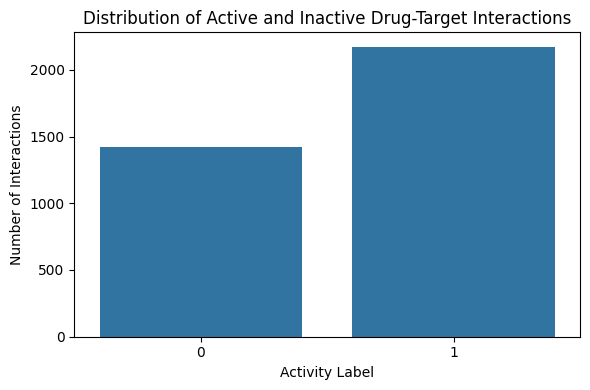

In [72]:
# 8. Activity Label Visualisation


plt.figure(figsize=(6,4))


sns.countplot(
    data=interactions_df,
    x="active"
)


plt.title(
    "Distribution of Active and Inactive Drug-Target Interactions"
)


plt.xlabel(
    "Activity Label"
)


plt.ylabel(
    "Number of Interactions"
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "baseline_activity_distribution.png"
    ),
    dpi=300
)


plt.show()

In [73]:
# 9. Prepare Features and Labels


X = np.array(
    interactions_df["fingerprint"].tolist()
)


y = interactions_df["active"]


print(
    "Feature shape:",
    X.shape
)


print(
    "Label shape:",
    y.shape
)

Feature shape: (3590, 1024)
Label shape: (3590,)


In [74]:
# 10. Split Training and Testing Data


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(
    "Training samples:",
    X_train.shape[0]
)


print(
    "Testing samples:",
    X_test.shape[0]
)

Training samples: 2872
Testing samples: 718


In [75]:
# 11. Train Random Forest Model


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


rf_model.fit(
    X_train,
    y_train
)


print(
    "Random Forest model trained successfully."
)

Random Forest model trained successfully.


In [76]:
# 12. Generate Predictions


y_pred = rf_model.predict(
    X_test
)


y_probability = rf_model.predict_proba(
    X_test
)[:,1]


print(
    "Predictions generated successfully."
)

Predictions generated successfully.


In [77]:
# 13. Model Evaluation Metrics


accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred
)


recall = recall_score(
    y_test,
    y_pred
)


f1 = f1_score(
    y_test,
    y_pred
)


roc_auc = roc_auc_score(
    y_test,
    y_probability
)


evaluation_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Score": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    }
)


display(
    evaluation_results
)

,Metric,Score
0,Accuracy,0.857939
1,Precision,0.850211
2,Recall,0.928571
3,F1 Score,0.887665
4,ROC-AUC,0.924000


In [78]:
# 14. Classification Report


print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.75      0.81       284
           1       0.85      0.93      0.89       434

    accuracy                           0.86       718
   macro avg       0.86      0.84      0.85       718
weighted avg       0.86      0.86      0.86       718



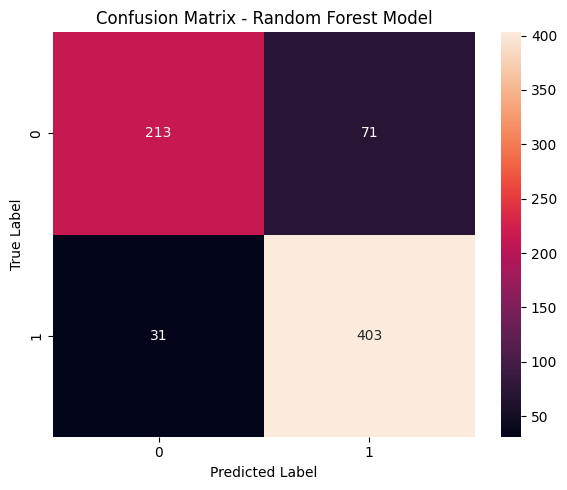

In [79]:
# 15. Confusion Matrix


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.title(
    "Confusion Matrix - Random Forest Model"
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "random_forest_confusion_matrix.png"
    ),
    dpi=300
)


plt.show()

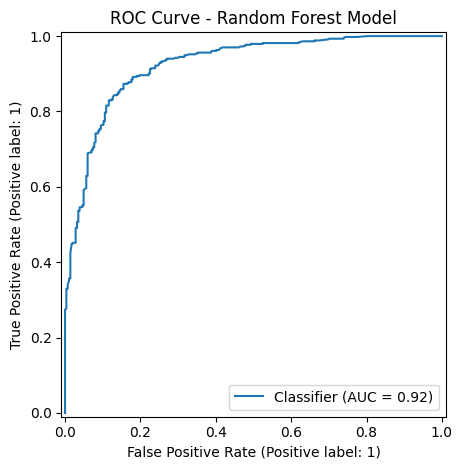

In [80]:

# 16. ROC Curve


RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)


plt.title(
    "ROC Curve - Random Forest Model"
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "random_forest_roc_curve.png"
    ),
    dpi=300
)


plt.show()

In [81]:
# 17. Cross-Validation Analysis


from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)


print(
    "Cross-validation ROC-AUC scores:"
)

print(cv_scores)


print(
    "\nAverage Cross-validation ROC-AUC:"
)

print(
    cv_scores.mean()
)

Cross-validation ROC-AUC scores:
[0.83606072 0.79573408 0.74958623 0.59588156 0.50911417]

Average Cross-validation ROC-AUC:
0.6972753526903965


In [82]:
# 18. Hyperparameter Tuning


from sklearn.model_selection import GridSearchCV


param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}


grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)


grid_search.fit(
    X_train,
    y_train
)


print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)


print(
    "\nBest Cross-validation ROC-AUC:"
)

print(
    grid_search.best_score_
)

Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}

Best Cross-validation ROC-AUC:
0.909993715259531


In [83]:
# 19. Feature Importance Analysis


best_rf_model = grid_search.best_estimator_


feature_importance = pd.DataFrame(
    {
        "Feature": range(
            len(best_rf_model.feature_importances_)
        ),
        "Importance": best_rf_model.feature_importances_
    }
)


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


display(
    feature_importance.head(20)
)

,Feature,Importance
624,624,0.010319
724,724,0.009373
135,135,0.008835
656,656,0.007172
881,881,0.006743
926,926,0.006721
456,456,0.006667
325,325,0.006516
212,212,0.006354
935,935,0.005698


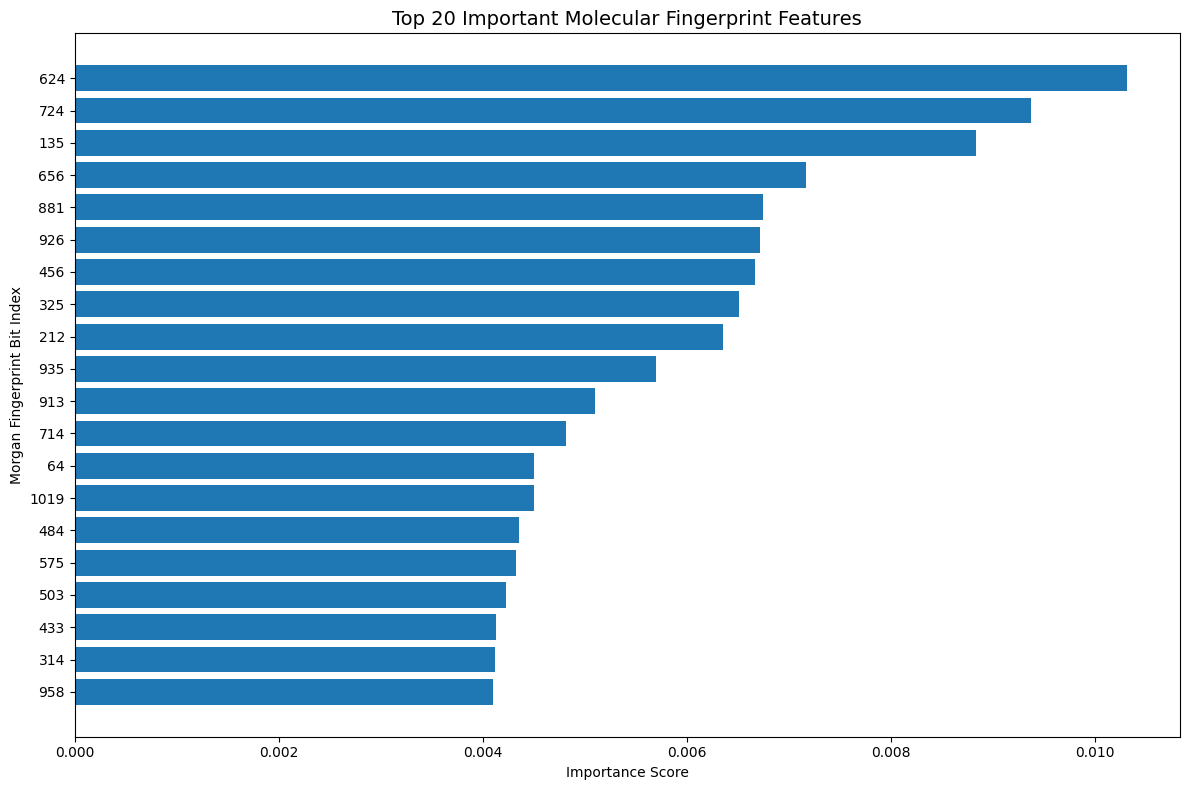

In [84]:
# Feature Importance Visualisation


top_features = feature_importance.head(20).copy()


# Convert feature index to string labels
top_features["Feature"] = (
    top_features["Feature"]
    .astype(str)
)


# Sort for horizontal plotting
top_features = top_features.sort_values(
    by="Importance",
    ascending=True
)


plt.figure(figsize=(12,8))


plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)


plt.title(
    "Top 20 Important Molecular Fingerprint Features",
    fontsize=14
)


plt.xlabel(
    "Importance Score"
)


plt.ylabel(
    "Morgan Fingerprint Bit Index"
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "random_forest_feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [85]:
# 20. Retrain Final Random Forest Model


final_rf_model = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)


final_rf_model.fit(
    X_train,
    y_train
)


print(
    "Final Random Forest model trained successfully."
)

Final Random Forest model trained successfully.


In [86]:
# 21. Save Trained Model


model_file = os.path.join(
    MODEL_PATH,
    "random_forest_model.joblib"
)


joblib.dump(
    final_rf_model,
    model_file
)


print(
    "Final Random Forest model saved successfully."
)

Final Random Forest model saved successfully.


In [87]:
# Final Model Evaluation


final_predictions = final_rf_model.predict(
    X_test
)


final_probability = final_rf_model.predict_proba(
    X_test
)[:,1]


final_evaluation_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Score": [
            accuracy_score(y_test, final_predictions),
            precision_score(y_test, final_predictions),
            recall_score(y_test, final_predictions),
            f1_score(y_test, final_predictions),
            roc_auc_score(y_test, final_probability)
        ]
    }
)


display(
    final_evaluation_results
)

,Metric,Score
0,Accuracy,0.856546
1,Precision,0.849894
2,Recall,0.926267
3,F1 Score,0.886439
4,ROC-AUC,0.930109


In [88]:
# 22. Save Evaluation Results


results_file = os.path.join(
    RESULTS_PATH,
    "random_forest_evaluation.csv"
)


final_evaluation_results.to_csv(
    results_file,
    index=False
)


print(
    "Evaluation results saved successfully."
)

Evaluation results saved successfully.


In [89]:
# 23. Save Cross-Validation Results


cv_results = pd.DataFrame(
    {
        "Fold": [1, 2, 3, 4, 5],
        "ROC-AUC": cv_scores
    }
)


cv_results.loc[len(cv_results)] = [
    "Average",
    cv_scores.mean()
]


cv_results_file = os.path.join(
    RESULTS_PATH,
    "random_forest_cross_validation.csv"
)


cv_results.to_csv(
    cv_results_file,
    index=False
)


print(
    "Cross-validation results saved successfully."
)

Cross-validation results saved successfully.


In [90]:
# 24. Download Generated Files


from google.colab import files


# Download trained model

files.download(model_file)


# Download final evaluation results

files.download(results_file)


# Download cross-validation results

files.download(cv_results_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary of Findings

This notebook developed a Random Forest machine learning model for predicting
drug–target interactions using molecular fingerprints generated from drug SMILES
structures.

A baseline model was trained using the processed interaction dataset, followed
by cross-validation and hyperparameter optimisation to improve model reliability
and performance.

Feature importance analysis was performed to identify influential molecular
fingerprint features used by the model during prediction.

The final optimised Random Forest model, evaluation metrics, and validation
results were saved for comparison with more advanced approaches developed in
later stages of the project, including protein embeddings and Graph Neural
Networks.